# View TissueStretch VTP files

Use this notebook to open `.vtp` files written by `run.py` or `run2.py` and visualize them with PyVista.

In [1]:
from pathlib import Path

import pyvista as pv

pv.set_jupyter_backend('static')

## Choose a VTP file

Edit `vtp_path` to point to the file you want to inspect.

In [2]:
vtp_path = Path('30x10/0/cells_fpull_0.1000_step_00000323.vtp')

if not vtp_path.exists():
    candidates = sorted(Path('.').rglob('*.vtp'))
    print(f'{vtp_path} was not found.')
    print('Available .vtp files:')
    for path in candidates[:20]:
        print('  ', path)
    if len(candidates) > 20:
        print(f'  ... {len(candidates) - 20} more')
else:
    print(f'Loading {vtp_path}')

Loading 30x10/0/cells_fpull_0.1000_step_00000323.vtp


## Load and inspect the file

In [3]:
mesh = pv.read(vtp_path)
mesh

PolyData (0x74e20845ed40)
  N Cells:    300
  N Points:   680
  N Strips:   0
  X Bounds:   -1.646e+01, 2.094e+01
  Y Bounds:   -3.662e+00, 4.550e+00
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   24

In [4]:
print('Point data arrays:')
for name in mesh.point_data.keys():
    print('  ', name)

print('\nCell data arrays:')
for name in mesh.cell_data.keys():
    print('  ', name)

Point data arrays:
   Id
   VertType
   Force

Cell data arrays:
   cell area
   Perimeter
   FaceId
   CellTypes
   NumNeigh
   cell energy
   StressXX
   StressYY
   StressXY
   Centerx
   Centery
   ShapeQxx
   ShapeQxy
   ShapeAnisotropy
   ShapeTheta
   LongAxisTheta
   LongAxis
   CellAspectRatio
   HexaticPsi6Re
   HexaticPsi6Im
   HexaticPsi6Abs


## Plot the tissue

Set `scalar_name` to one of the printed point or cell data arrays, or set it to `None` for a plain mesh.

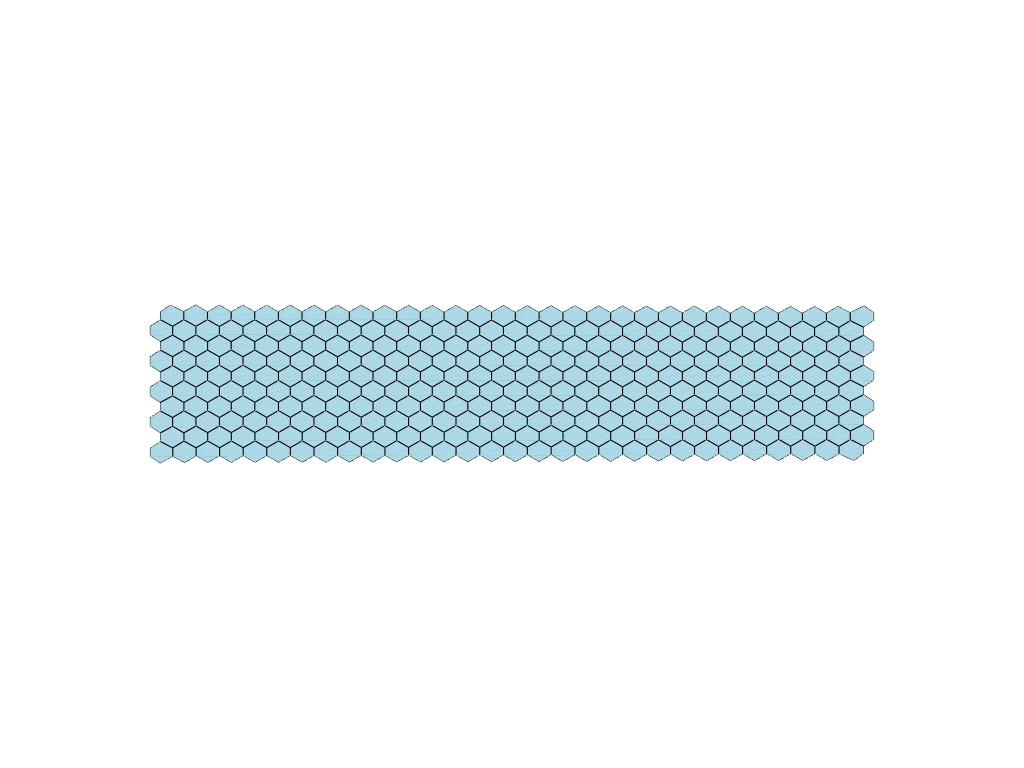

In [5]:
scalar_name = 'Area'

if scalar_name in mesh.cell_data:
    preference = 'cell'
elif scalar_name in mesh.point_data:
    preference = 'point'
else:
    scalar_name = None
    preference = 'cell'

plotter = pv.Plotter(notebook=True)
plotter.add_mesh(
    mesh,
    scalars=scalar_name,
    preference=preference,
    show_edges=True,
    line_width=1,
    lighting=False,
    cmap='viridis',
)
plotter.camera_position = 'xy'
plotter.show()

## Save a screenshot

In [ ]:
screenshot_path = vtp_path.with_suffix('.png')

plotter = pv.Plotter(off_screen=True)
plotter.add_mesh(
    mesh,
    scalars=scalar_name,
    preference=preference,
    show_edges=True,
    line_width=1,
    lighting=False,
    cmap='viridis',
)
plotter.camera_position = 'xy'
plotter.screenshot(str(screenshot_path))
plotter.close()

print(f'Saved {screenshot_path}')